# Kunitz Domain Characterization and HMM Model Evaluation

This notebook details a comprehensive bioinformatics workflow for the characterization of Kunitz domains, a family of protease inhibitors. The project involves data retrieval from the Protein Data Bank (PDB), rigorous data cleaning and sequence clustering to ensure data quality, and structural alignment to identify conserved motifs. A Hidden Markov Model (HMM) is then built to capture the unique sequence patterns of Kunitz domains. Finally, the model's predictive performance is thoroughly evaluated using both positive and negative datasets derived from UniProt, culminating in the determination of an optimal E-value threshold and assessment of its classification accuracy.

## Preparing the enviorment

Installing all the librarues and packages requier for the analysis


In [ ]:
# Install HMMER suite for hmmbuild and hmmsearch
!sudo apt-get update
!sudo apt-get install hmmer

# Install MMseqs2 for sequence clustering
!sudo apt-get install mmseqs2

Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


In [ ]:
# Install mtm-align from the bioconda channel
!mamba install -c conda-forge -c bioconda mtm-align -y


Looking for: ['mtm-align']

[+] 0.0s
bioconda/linux-64 ..  ⣾  bioconda/linux-64 (check zst)                     
[+] 0.0s
bioconda/noarch (c..  ⣾  bioconda/noarch (check zst)                       
[+] 0.0s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  
bioconda/linux-64     ⣾  
bioconda/noarch       ⣾  [+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  
bioconda/linux-64     ⣾  
bioconda/noarch       ⣾  [+] 0.2s
conda-forge/linux-64   7%
conda-forge/noarch     7%
bioconda/linux-64     25%
bioconda/noarch       10%[+] 0.3s
conda-forge/linux-64  10%
conda-forge/noarch    15%
bioconda/linux-64     60%
bioconda/noarch       45%[+] 0.4s
conda-forge/linux-64  14%
conda-forge/noarch    22%
bioconda/linux-64     92%
bioconda/noarch       80%bioconda/linux-64                                 
bioconda/noarch                                   
[+] 0.5s
conda-forge/linux-64  17%
conda-forge/noarch    28%[+] 0.6s
conda-forge/linux-64  22%
conda-forge/noarch    38%[+] 0.7s
conda-forg

In [ ]:
! conda install bioconda::mtm-align

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - bioconda::mtm-align


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    mtm-align-20220104         |       h9948957_3         142 KB  bioconda
    openssl-3.6.2              |       h35e630c_0         3.0 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         4.6 MB

The following NEW packages will be INSTALLED:

  mtm-align          bioconda/linux-64::mtm-align-20220104-h9948957_3 

The following p

In [ ]:
import pandas as pd
import requests      # Import requests for HTTP requests to the PDB API
import numpy as np
from sklearn.metrics import roc_curve, auc

## Data Retrieval and Initial Processing

The following Python code retrieves protein structure data from the Protein Data Bank (PDB) via its GraphQL API. It then processes the retrieved JSON data to create a Pandas DataFrame containing relevant attributes for further analysis. The script filters for sequences between 40 and 80 residues and includes only those with Pfam annotations.

In [ ]:
# Prepare PDB IDs for the GraphQL query
ids_str = ''  # Initialize an empty string to build the list of IDs for the query
ids = pd.Series(pd.read_csv('/content/drive/MyDrive/Files_Kunitz_domains/ids_pdb.csv', header=1)['Entry ID'])  # Read IDs into a pandas Series
for i in range(ids.shape[0]):
    ids_str += '"' + ids[i] + '",'  # Append each ID in quotes, separated by commas
ids_str = ids_str[:-1]  # Remove the trailing comma

# Define the GraphQL query to fetch data for the specified PDB entries
query = '''
{
  entries(entry_ids: [%s])
  {
    rcsb_id
    rcsb_entry_container_identifiers {
      entry_id
    }
    rcsb_entry_info {
      diffrn_resolution_high {
        value
      }
    }
    polymer_entities {
      entity_poly {
        pdbx_seq_one_letter_code_can
        rcsb_sample_sequence_length
      }
      polymer_entity_instances {
        rcsb_polymer_entity_instance_container_identifiers {
          auth_asym_id
        }
      }
      rcsb_polymer_entity_annotation {
        type
      }
      rcsb_polymer_entity_container_identifiers {
        reference_sequence_identifiers {
          database_accession
        }
      }
    }
  }
} ''' %ids_str #%s will be replaced with the ids_str

# Send the GET request to the PDB GraphQL endpoint
p = requests.get('https://data.rcsb.org/graphql?query=%s' % requests.utils.requote_uri(query))

# Parse the JSON response
j = p.json()
pdb = j['data']['entries']  # Extract the list of entries

# Initialize an empty list to store dictionaries of extracted data
df_pdb = []

# Loop through each PDB entry
for i in range(ids.shape[0]):
    resolution = float(pdb[i]['rcsb_entry_info']['diffrn_resolution_high']['value'])  # Extract resolution as float
    for j_entity in pdb[i]['polymer_entities']:  # Loop through polymer entities in the entry
        len_seq = int(j_entity['entity_poly']['rcsb_sample_sequence_length'])  # Get sequence length
        if len_seq > 80 or len_seq < 40:  # Filter sequences outside 40-80 residues
            continue
        seq = j_entity['entity_poly']['pdbx_seq_one_letter_code_can']  # Extract sequence
        annot_type = j_entity['rcsb_polymer_entity_annotation'][0]['type']  # Extract annotation type
        chain = j_entity['polymer_entity_instances'][0]['rcsb_polymer_entity_instance_container_identifiers']['auth_asym_id']  # Extract chain ID

        # Append a list of attributes to the df list
        df_pdb.append([ids[i], seq, len_seq, resolution, annot_type, chain])

# Create a Pandas DataFrame from the dictionary
df_pdb = pd.DataFrame(df_pdb, columns=['PDB_ID', 'Sequence', 'Length', 'Resolution', 'Annotation_type', 'Chain'])
display(df_pdb.head())

,PDB_ID,Sequence,Length,Resolution,Annotation_type,Chain
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,58,1.60,Pfam,B
1,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,58,1.50,Pfam,B
2,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,2.63,Pfam,J
3,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,1.09,Pfam,A
4,1BPI,RPDFCLEPPYTGPCKARIIRYFANAKAGLCQTFVYGGCRAKRNNFK...,58,2.00,Pfam,A


In [ ]:
df_pdb.shape

(140, 6)

This code generates a DataFrame (`df_pdb`) containing key protein attributes: PDB ID, sequence, length, resolution, annotation type, and chain identifier. This DataFrame serves as the foundational dataset for subsequent filtering and analysis steps within the workflow. A total of 140 entries were obtained during this initial retrieval and processing phase.

## Removing Duplicate Entries and Filtering by Annotation Type

This step focuses on cleaning the `df_pdb` DataFrame by removing duplicate entries and retaining only those associated with 'Pfam' annotations. Duplicates can arise from various sources, such as multiple chains within the same PDB entry or redundant data, and their removal is crucial for maintaining data integrity. By specifically filtering for 'Pfam' annotations, we ensure that the subsequent analysis is based exclusively on relevant Kunitz domains, thereby enhancing the specificity and accuracy of our study.

In [ ]:
# Identify PDB_IDs that appear more than once in the DataFrame
duplicated_pdb_entries = df_pdb[df_pdb.duplicated(subset=['PDB_ID'], keep=False)]

# Extract the unique PDB_IDs that are duplicated
duplicated_pdb_ids = duplicated_pdb_entries['PDB_ID'].unique()

print(f"Found {len(duplicated_pdb_ids)} PDB_IDs with duplicate entries:")
display(pd.Series(duplicated_pdb_ids))


Found 6 PDB_IDs with duplicate entries:


,0
0,1D0D
1,2IJO
2,2KAI
3,3U1J
4,5YVU
5,5YW1


As observed, some entries are redundantly annotated by both Gene Ontology (GO) and Pfam. For consistency and relevance to Kunitz domains, we will retain only those entries specifically annotated by Pfam.

In [ ]:
# Filter the DataFrame to keep only entries with 'Pfam' annotation type.
df_pdb = df_pdb.query('Annotation_type == "Pfam"').reset_index(drop=True)
df_pdb

,PDB_ID,Sequence,Length,Resolution,Annotation_type,Chain
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,58,1.60,Pfam,A
1,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,58,1.50,Pfam,A
2,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,2.80,Pfam,A
3,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,2.63,Pfam,A
4,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,1.09,Pfam,A
...,...,...,...,...,...,...
130,7QIR,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,1.90,Pfam,H
131,7QIS,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,1.83,Pfam,D
132,7QIT,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,58,1.99,Pfam,D
133,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,58,1.80,Pfam,A


## Sequence Clustering

To prevent biases in downstream analyses due to highly similar sequences, we will perform sequence clustering. This process groups sequences based on their similarity, allowing us to select representative sequences from each cluster.

First, the protein sequences extracted from the PDB will be formatted into FASTA files, a standard format for biological sequences. Subsequently, we will use **MMseqs2**, a fast and sensitive sequence search and clustering suite, to generate these clusters and select a representative sequence for each. MMseqs2 will identify redundant sequences and group them, providing a non-redundant set for further analysis. This step is crucial for building a robust Hidden Markov Model (HMM) that accurately captures the characteristics of the Kunitz domain family.

In [ ]:
# creating a Fasta file with the sequences and the PDB ids as headers
with open('sequences_kd.fasta', 'w') as f:
    for i in range(df_pdb.shape[0]):
        f.write('>' + df_pdb['PDB_ID'][i] + '\n')
        f.write(df_pdb['Sequence'][i] + '\n')

NameError: name 'sequences_kd' is not defined

In [ ]:
# Create a database from the FASTA file using mmseqs2.
! mmseqs createdb sequences_kd.fasta sequences_kdDB

# Clustering the sequences
! mmseqs cluster sequences_kdDB cluster_kdDB tmp --min-seq-id 0.95 -c 0.85 --cov-mode 2

# Saving the cluster in a tsv file
! mmseqs createtsv sequences_kdDB sequences_kdDB cluster_kdDB cluster.tsv

# Counting how many cluster where made (20 clusters)
! cut -f1 cluster.tsv | sort | uniq | wc -l

# Retrieve the representative sequences of each cluster and store them in a new database.
! mmseqs createsubdb cluster_kdDB sequences_kdDB representative_seqDB

# Convert the mmseqs2 database of representative sequences to a FASTA file.
! mmseqs convert2fasta representative_seqDB representative_seq.fasta

sequences_kdDB exists and will be overwritten
createdb sequences_kd.fasta sequences_kdDB 

MMseqs Version:       	13-45111+ds-2
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[102] 0s 3ms
Time for merging to sequences_kdDB_h: 0h 0m 0s 2ms
Time for merging to sequences_kdDB: 0h 0m 0s 1ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 9ms
cluster sequences_kdDB cluster_kdDB tmp --min-seq-id 0.95 -c 0.85 --cov-mode 2 

MMseqs Version:                     	13-45111+ds-2
Substitution matrix                 	nucl:nucleotide.out,aa:blosum62.out
Seed substitution matrix            	nucl:nucleotide.out,aa:VTML80.out
Sensitivity                         	4
k-mer length                        	0
k-score                             	2147483647
Alphabet size                       	nucl:5,aa:21
Max sequence length                 	65535
Max r

## Structural Alignment

Having obtained a set of representative sequences through MMseqs2 clustering, the next phase involves retrieving their corresponding structural information and preparing them for alignment. This multi-step process is crucial for understanding the structural diversity and conserved features within the Kunitz domain family.

### Parsing Representative Sequences

The `representative_seq.fasta` file, generated by MMseqs2, contains the chosen representative sequence for each cluster. We will parse this FASTA file within Python to extract the unique PDB IDs of these sequences.

In [ ]:
# reading IDs of representative sequences from the Fasta file
representative_sequences = []
with open('/content/drive/MyDrive/Files_Kunitz_domains/representative_seq.fasta', 'r') as f:
    for line in f:
        if line.startswith('>'):
            representative_sequences.append(line[1:].strip())  # to exclude the '>'

### Files for Structural Alignment

For each identified PDB ID, we will programmatically download its corresponding Protein Data Bank (PDB) file, preferably in CIF (Crystallographic Information File) format. These files contain detailed atomic coordinates and experimental data for the protein structures.

However, PDB entries can sometimes contain multiple protein chains. Based on the `Chain` information stored in our DataFrame (`df_pdb`), we will extract only the relevant chain(s) from each downloaded CIF file that correspond to our Kunitz domain sequences.

In [ ]:
# Downloading the cif files
for i in representative_sequences:
    url = f"https://files.rcsb.org/download/{i}.pdb"
    r = requests.get(url)
    with open(f"{i}.pdb", 'wb') as f:
        f.write(r.content)

# Exctracting the chain
for i in representative_sequences:    # parse a PDB file (open file and exctarct possition for every atom)
    pdb_line = []
    chain = df_pdb.query('PDB_ID ==@i')['Chain'].iloc[0]
    with open(f"{i}.pdb", 'r') as f:
        for line in f:
            if line.find ("ATOM") != 0 :       # select lines with "ATOMS"
                continue
            if line[21] != chain:              # Just select chain that matches the input
                continue
            pdb_line.append(line.rstrip())

    # create a new file with the correct chain information
    name = f"/content/drive/MyDrive/Files_Kunitz_domains/{i}_{chain}.pdb"
    with open(name, 'w') as f:
        for ele in pdb_line:
            f.write(ele + '\n')

### Structural Alignment

Finally, the extracted protein chains will be subjected to structural alignment. This step is essential for identifying conserved structural motifs and variations among the Kunitz domains, which is a prerequisite for building an accurate Hidden Markov Model (HMM) that captures the family's characteristics.

Two methods were evaluated:

*   **PDBe-Fold**: This service, provided by the Protein Data Bank in Europe (PDBe), offers robust structural alignment functionalities. It is a reliable tool for comparing protein structures.
*   **mtm_alignment**: This refers to a Multiple-sequence/structure-based Target-ligand Modeling alignment approach, often employed for aligning protein structures, particularly in the context of ligand binding.

Exploring both PDBe-Fold and mtm_alignment provides a more robust approach to structural alignment. While PDBe-Fold is powerful, it can sometimes experience delays or server unavailability. Having an alternative like mtm_alignment ensures that structural comparisons can proceed even if one service is temporarily inaccessible, maintaining the continuity of the workflow.

In [ ]:
! mtm-align -i structural_alg.txt

structural_alg.txt does not exist, please try again


After restarting the runtime, run the following cell to install `mtm-align` using `mamba` from `bioconda`.

Based on both sequence and structural alignments, problematic entries such as 2KAI_A.pdb and 4BQD_A.pdb were identified and subsequently removed. These entries exhibited initial sections that did not correspond to homologous regions in other sequences, which could introduce inaccuracies into the alignment. Their exclusion ensures that the alignment focuses exclusively on truly homologous regions, thereby contributing to a more accurate Hidden Markov Model (HMM).

Additionally, to ensure a uniform length across all sequences for consistent HMM building, the sequences were truncated to a length of 139 residues.

In [ ]:
# filtering long sequences
mtm_seq = open('/content/drive/MyDrive/Files_Kunitz_domains/mtm_structutal_alg.fasta', 'w')
with open('/content/drive/MyDrive/Files_Kunitz_domains/filtered_mtm_result.fasta', 'r') as f:
    for line in f:
        if line.startswith('>'):
            mtm_seq.write(line.rstrip()+'\n')
            continue
        if len(line) > 139:
            line = line[0:139]
        mtm_seq.write(line.rstrip() + '\n')
mtm_seq.close()

## Building the HMM Model

The `hmmbuild` command from the HMMER suite is used to construct a Hidden Markov Model (HMM) from a multiple sequence alignment. In this specific case, `kunitz_model_mtm.hmm` will be the output HMM file, and `mtm_structutal_alg.fasta` serves as the input multiple sequence alignment in FASTA format. This input alignment was generated from the structural alignment of Kunitz domains. The resulting HMM will effectively capture the characteristic sequence patterns and conserved features of the Kunitz domain protein family.

In [ ]:
! hmmbuild --amino kunitz_model_mtm.hmm mtm_structutal_alg.fasta

Alignment input open failed.
   couldn't open mtm_structutal_alg.fasta for reading


## Model Evaluation

For model evaluation, positive and negative datasets were obtained from UniProt. Review entries with Pfam PF00014 annotation were labeled as the positive set (398 entries), while review entries not annotated as Kunitz domains were used as a negative set (574,229 entries). HMMsearch was then performed on both sets using the selected mTM model. The outputs were parsed into DataFrames containing target names, e-values, scores, biases, and corresponding labels (1 for positive, 0 for negative).

In [ ]:
! zcat -f UniprotSearch/positive.gz | grep ">" | wc -l # checking the number of sequences in the positive set
# 398 entries where retriven

! zcat -f UniprotSearch/negatives.gz | grep ">" | wc -l
# 574229 entries where retriven

# Running the hmmsearch with the mtm model in the positive set
! hmmsearch -Z 1000 --noali --max --tblout kunitz_table_positive.txt kunitz_model_mtm.hmm UniprotSearch/positive

# Running the hmmsearch with the mtm model in the negative set
! hmmsearch -Z 1000 --noali --max --tblout kunitz_table_negatives.txt kunitz_model_mtm.hmm UniprotSearch/negatives

# Exctracting the ids of the sequences in the negative set, later will be used to build the negative set
! grep ">" UniprotSearch/negatives | awk '{print $1}'| tr -d ">" | sort > negatives_kunitz.ids

! awk '{print $1 " 100 0 0 0"}' negatives_kunitz.ids > negatives_kunitz.csv

From the hmmsearch, 2 sets were build

In [ ]:
# Construction of positive set

#EXtracting information from the hmmsearch output tables for the full sequences
cols = ["target_name", "e_value", "score", "bias"]

df_positive = pd.read_csv('/content/drive/MyDrive/Files_Kunitz_domains/kunitz_table_positive.txt',sep=r'\s+', comment='#', header=None, usecols=[0, 4, 5, 6], names=cols)
df_positive['label'] = 1      # Label for positive hits is 1
df_positive['target_name'] = df_positive['target_name'].str.split('|').str[1]
df_positive.sort_values(by='e_value', inplace=True)
df_positive


,target_name,e_value,score,bias,label
0,Q868Z9,4.600000e-189,608.6,187.0,1
1,O76840,2.000000e-180,580.9,134.4,1
2,A0A6P8HC43,3.100000e-94,304.8,61.0,1
3,Q02445,9.000000e-67,216.8,36.2,1
4,P10646,1.100000e-66,216.6,35.0,1
...,...,...,...,...,...
393,Q11101,2.700000e-07,26.3,7.7,1
394,Q8WPG5,2.100000e-05,20.3,4.7,1
395,A0A1Q1NL17,3.500000e-04,16.3,4.7,1
396,O62247,2.200000e-03,13.8,1.0,1


In [ ]:
# Eliminating first lines of positive to avoid posible overfitting
df_positive = df_positive[3:]
df_positive

,target_name,e_value,score,bias,label
3,Q02445,9.000000e-67,216.8,36.2,1
4,P10646,1.100000e-66,216.6,35.0,1
5,Q28864,1.100000e-66,216.5,35.4,1
6,P19761,1.100000e-65,213.3,33.2,1
7,O54819,7.900000e-65,210.6,35.0,1
...,...,...,...,...,...
393,Q11101,2.700000e-07,26.3,7.7,1
394,Q8WPG5,2.100000e-05,20.3,4.7,1
395,A0A1Q1NL17,3.500000e-04,16.3,4.7,1
396,O62247,2.200000e-03,13.8,1.0,1


In [ ]:
# Construction of the negative set

df_negative = pd.read_csv('/content/drive/MyDrive/Files_Kunitz_domains/kunitz_table_negatives.txt',sep=r'\s+', comment='#', header=None, usecols=[0, 4, 5, 6], names=cols)
df_negative['label'] = 0      # Label for negative hits is 0'
df_negative['target_name'] = df_negative['target_name'].str.split('|').str[1]
df_negative.sort_values(by='e_value', inplace=True)
df_negative

,target_name,e_value,score,bias,label
0,P84555,6.400000e-07,25.1,0.0,0
1,P83605,1.500000e-05,20.8,0.1,0
2,P0DJ63,3.300000e-05,19.6,0.1,0
3,Q09JW3,9.800000e-05,18.1,4.1,0
4,Q09JW4,1.100000e-04,18.0,5.0,0
...,...,...,...,...,...
5472,Q6IPR1,1.000000e+01,2.1,0.2,0
5475,Q9KH11,1.000000e+01,2.1,0.0,0
5474,Q500S4,1.000000e+01,2.1,0.1,0
5473,O49139,1.000000e+01,2.1,0.1,0


The maximan E-val is 1, so for the negatives ids that are not matching according to de model a fictiona; e -value od 100 will be added

In [ ]:
# Integrating the negatives ids that did not have hits in the hmmsearch output
cols = ["target_name", "e_value", "score", "bias", "label"]
negatives_kunitz_ids = pd.read_csv('/content/drive/MyDrive/Files_Kunitz_domains/negatives_kunitz.csv',sep=' ', header=None, names=cols, index_col=False)
negatives_kunitz_ids

,target_name,e_value,score,bias,label
0,A0A009IHW8,100,0,0,0
1,A0A011QK89,100,0,0,0
2,A0A017SE81,100,0,0,0
3,A0A017SE85,100,0,0,0
4,A0A017SEF3,100,0,0,0
...,...,...,...,...,...
574224,X5LX76,100,0,0,0
574225,X5M5N0,100,0,0,0
574226,X5M8U1,100,0,0,0
574227,X6R8D5,100,0,0,0


In [ ]:
# converting the values from string to float
negatives_kunitz_ids['e_value'] = negatives_kunitz_ids['e_value'].astype(float)
negatives_kunitz_ids['score'] = negatives_kunitz_ids['score'].astype(float)
negatives_kunitz_ids['bias'] = negatives_kunitz_ids['bias'].astype(float)

# Updating the negative DataFrame with the negatives that did not have hits in the hmmsearch output
df_negative.set_index('target_name', inplace=True)
negatives_kunitz_ids.set_index('target_name', inplace=True)
negatives_kunitz_ids.update(df_negative)

# Displaying the values
negatives_kunitz_ids.sort_values(by='e_value', inplace=True)
negatives_kunitz_ids

,e_value,score,bias,label
target_name,,,,
P84555,6.400000e-07,25.1,0.0,0
P83605,1.500000e-05,20.8,0.1,0
P0DJ63,3.300000e-05,19.6,0.1,0
Q09JW3,9.800000e-05,18.1,4.1,0
Q09JW4,1.100000e-04,18.0,5.0,0
...,...,...,...,...
X5M5N0,1.000000e+02,0.0,0.0,0
X5M8U1,1.000000e+02,0.0,0.0,0
X6R8D5,1.000000e+02,0.0,0.0,0


In [ ]:
negatives_kunitz_ids = negatives_kunitz_ids.reset_index()

The combined datasets were shuffled and split into two halves for cross-validation. The first set will be used to determine the optimal E-value threshold, ranging from $10^{-1}$ to $10^{-14}$. The second set will then be used to evaluate the actual performance of the model in predicting labels (Kunitz or non-Kunitz) using the optimized E-value threshold derived from the first set.

In [ ]:
# generating the dataset for the cross validation
df_positive_shuffled = df_positive.sample(frac=1, random_state=42).reset_index(drop=True)
df_positive_shuffled_1 = df_positive_shuffled[:df_positive_shuffled.shape[0]//2]
df_positive_shuffled_2 = df_positive_shuffled[df_positive_shuffled.shape[0]//2:]

df_negative_shuffled = negatives_kunitz_ids.sample(frac=1, random_state=42).reset_index(drop=True)
df_negative_shuffled_1 = df_negative_shuffled[:df_negative_shuffled.shape[0]//2]
df_negative_shuffled_2 = df_negative_shuffled[df_negative_shuffled.shape[0]//2:]

df_set1= pd.concat([df_positive_shuffled_1, df_negative_shuffled_1], ignore_index=True)
df_set2= pd.concat([df_positive_shuffled_2, df_negative_shuffled_2], ignore_index=True)

In [ ]:
# Assesing the performance on the first set to determine the optimal treshold
evaluation_set1 = []

# Constructiong the confusion matrix for the first set
for exp in range(1, 15):
    thresholds = 10**-exp
    confusion_matrix = np.zeros((2,2))   # initializing a empty confusion matrix
    for k in range (0, df_set1.shape[0]):
        j = 0
        label = df_set1.iloc[k]['label']  # getting the true class (0 or 1)
        if df_set1.iloc[k]['e_value'] < thresholds and label == 1:   # if the e-value is smaller than the threshold and the true class is 1, we predict 1
            confusion_matrix[0,0] = confusion_matrix[0,0]+1  # true positive
        if df_set1.iloc[k]['e_value'] >= thresholds and label == 0:
            confusion_matrix[1,1] = confusion_matrix[1,1]+1  # true negative
        if df_set1.iloc[k]['e_value'] < thresholds and label == 0:   # if the e-value is smaller than the threshold but the true class is 0, we predict 1
            confusion_matrix[1,0] = confusion_matrix[1,0]+1  #false positive
        if df_set1.iloc[k]['e_value'] >= thresholds and label == 1:
                confusion_matrix[0,1] = confusion_matrix[0,1]+1  # false negative
    # Acuracy
    accuracy = (confusion_matrix[0,0] + confusion_matrix[1,1]) / np.sum(confusion_matrix)
    mcc = (confusion_matrix[0,0]*confusion_matrix[1,1] - confusion_matrix[0,1]*confusion_matrix[1,0]) / np.sqrt((confusion_matrix[0,0]+confusion_matrix[0,1])*(confusion_matrix[0,0]+confusion_matrix[1,0])*(confusion_matrix[1,1]+confusion_matrix[0,1])*(confusion_matrix[1,1]+confusion_matrix[1,0]))
    print('For threshold', thresholds, 'Accuracy:', accuracy, 'MCC:', mcc)
    evaluation_set1.append([thresholds, accuracy, mcc])

evaluation_set1 = pd.DataFrame(evaluation_set1, columns=['threshold', 'accuracy', 'mcc'])


For threshold 0.1 Accuracy: 0.999885141884578 MCC: 0.9254314092121534
For threshold 0.01 Accuracy: 0.9999686750594303 MCC: 0.9778960592426069
For threshold 0.001 Accuracy: 0.9999825972552391 MCC: 0.9874250667024667
For threshold 0.0001 Accuracy: 0.9999895583531434 MCC: 0.9924030235610568
For threshold 1e-05 Accuracy: 0.9999895583531434 MCC: 0.992364404850876
For threshold 1e-06 Accuracy: 0.9999895583531434 MCC: 0.992364404850876
For threshold 1e-07 Accuracy: 0.9999860778041912 MCC: 0.9897887566506329
For threshold 1e-08 Accuracy: 0.9999860778041912 MCC: 0.9897887566506329
For threshold 1e-09 Accuracy: 0.9999860778041912 MCC: 0.9897887566506329
For threshold 1e-10 Accuracy: 0.9999860778041912 MCC: 0.9897887566506329
For threshold 1e-11 Accuracy: 0.9999825972552391 MCC: 0.9872194877266692
For threshold 1e-12 Accuracy: 0.9999721556083826 MCC: 0.9794713531823258
For threshold 1e-13 Accuracy: 0.9999651945104782 MCC: 0.9742717887987568
For threshold 1e-14 Accuracy: 0.9999443112167651 MCC: 0.

In [ ]:
evaluation_set1.sort_values(by='mcc', ascending=False, inplace=True)
evaluation_set1

,threshold,accuracy,mcc
3,1.000000e-04,0.999990,0.992403
4,1.000000e-05,0.999990,0.992364
5,1.000000e-06,0.999990,0.992364
8,1.000000e-09,0.999986,0.989789
7,1.000000e-08,0.999986,0.989789
6,1.000000e-07,0.999986,0.989789
9,1.000000e-10,0.999986,0.989789
2,1.000000e-03,0.999983,0.987425
10,1.000000e-11,0.999983,0.987219
11,1.000000e-12,0.999972,0.979471


In [ ]:
# Validating the model with the second set
thresholds = 10**-5
false_negatives = []
false_positives = []

confusion_matrix2 = np.zeros((2,2))   # initializing a empty confusion matrix
for k in range (0, df_set1.shape[0]):
    j = 0
    label = df_set1.iloc[k]['label']  # getting the true class (0 or 1)
    if df_set2.iloc[k]['e_value'] < thresholds and label == 1:   # if the e-value is smaller than the threshold and the true class is 1, we predict 1
        confusion_matrix2[0,0] = confusion_matrix2[0,0]+1  # true positive
    if df_set2.iloc[k]['e_value'] >= thresholds and label == 0:
        confusion_matrix2[1,1] = confusion_matrix2[1,1]+1  # true negative
    if df_set2.iloc[k]['e_value'] < thresholds and label == 0:   # if the e-value is smaller than the threshold but the true class is 0, we predict 1
        confusion_matrix2[1,0] = confusion_matrix2[1,0]+1  #false negative
        false_negatives.append(df_set2.iloc[k])
    if df_set2.iloc[k]['e_value'] >= thresholds and label == 1:
        confusion_matrix2[0,1] = confusion_matrix2[0,1]+1  # false positives
        false_positives.append(df_set2.iloc[k])

# Acuracy
print(confusion_matrix2)
accuracy = (confusion_matrix2[0,0] + confusion_matrix2[1,1]) / np.sum(confusion_matrix2)
mcc = (confusion_matrix2[0,0]*confusion_matrix2[1,1] - confusion_matrix2[0,1]*confusion_matrix2[1,0]) / np.sqrt((confusion_matrix2[0,0]+confusion_matrix2[0,1])*(confusion_matrix2[0,0]+confusion_matrix2[1,0])*(confusion_matrix2[1,1]+confusion_matrix2[0,1])*(confusion_matrix2[1,1]+confusion_matrix2[1,0]))
print('For threshold', thresholds, 'Accuracy:', accuracy, 'MCC:', mcc)

[[1.95000e+02 2.00000e+00]
 [1.00000e+00 2.87113e+05]]
For threshold 1e-05 Accuracy: 0.9999895583531434 MCC: 0.992364404850876


In [ ]:
# Analysis of false positive
false_positives

[target_name    A0A1Q1NL17
 e_value           0.00035
 score                16.3
 bias                  4.7
 label                   1
 Name: 163, dtype: object,
 target_name    D3GGZ8
 e_value          0.12
 score             8.3
 bias              3.4
 label               1
 Name: 190, dtype: object]

In [ ]:
# Analysis of false negatives
false_negatives

[target_name    A8Y7N9
 e_value           0.0
 score            83.1
 bias              7.5
 label               1
 Name: 197, dtype: object]

In [ ]:
# Roc curve and AUC
y_true = df_set2['label']
y_scores = -np.log10(df_set2['e_value'])  # using the negative log of the e-value as the score for the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print('AUC:', roc_auc)

AUC: 0.9999992787882658


(0.0, 1.0)

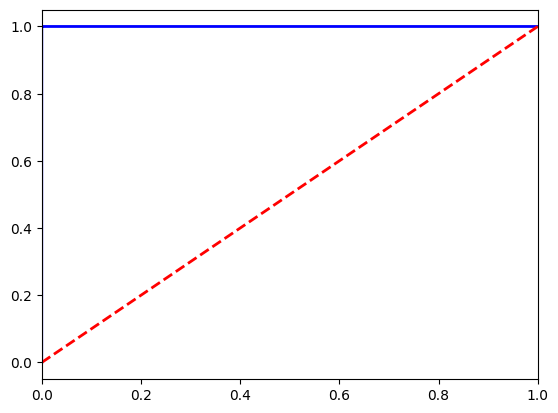

In [ ]:
# plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # line for random classifier
plt.xlim([0.0, 1.0])

In [ ]:
name = "fold_"+str(i)